# Transfer learning based network

In [ ]:
# library used to save trained models into the .onnx format
# if used, a colab session restart is needed after this command
!pip install --upgrade protobuf onnx tf2onnx -q

In [2]:
# download the EmoDB german dataset
!pip install -q audformat soundfile

import os
if not os.path.exists('emodb'):
    !wget -nc -q https://zenodo.org/record/7447302/files/emodb.zip
    !unzip -o -q emodb.zip -d .

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.9/74.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.0/325.0 kB 31.9 MB/s eta 0:00:00


In [12]:
from pathlib import Path

import audformat
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

keras.utils.set_random_seed(42)
print('GPU:', tf.config.list_physical_devices('GPU'))

# parameters for the spectrogram function
SR = 16000 # sampling rate
N_MELS = 128 # mel scale
N_FFT = 1024 # number of samples per frame
HOP_LENGTH = 256 # number of samples per step

# parameters for the sample segmentation function
WINDOW_SEC = 1.0
HOP_SEC = 0.5

db = audformat.Database.load('emodb')
db_root = Path(db.root)
df_train = db['emotion.categories.train.gold_standard'].get()
df_test = db['emotion.categories.test.gold_standard'].get()
print(f'samples in train: {len(df_train)}, test: {len(df_test)}')

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
samples in train: 304, test: 231


In [4]:
# speakers are identified by the first 2-digit number code on each .wav file
def get_speaker(filename):
    return Path(filename).stem[:2]

# function that returns the spectrogram of an audio chunk
def to_mel(chunk):
    mel = librosa.feature.melspectrogram(y=chunk, sr=SR, n_mels=N_MELS,
                                         n_fft=N_FFT, hop_length=HOP_LENGTH)
    return librosa.power_to_db(mel, ref=1.0)

# segmentation function (samples are divided into 1 second long windows with 50% overlap)
def window_audio(y):
    win, hop = int(WINDOW_SEC * SR), int(HOP_SEC * SR)
    if len(y) <= win:
        return [np.pad(y, (0, win - len(y)))]
    return [y[s:s + win] for s in range(0, len(y) - win + 1, hop)]

# training and testing datasets are created, separating different speakers
def build_dataset(df):
    specs, labels, speakers, files = [], [], [], []
    for filepath, label in zip(df.index.get_level_values('file'), df['emotion']):
        y, file_sr = sf.read(db_root / filepath, dtype='float32')
        if file_sr != SR:
            y = librosa.resample(y, orig_sr=file_sr, target_sr=SR)
        for chunk in window_audio(y):
            specs.append(to_mel(chunk))
            labels.append(label)
            speakers.append(get_speaker(filepath))
            files.append(str(filepath))
    return np.stack(specs), np.array(labels), np.array(speakers), np.array(files)

X_train, y_train, spk_train, files_train = build_dataset(df_train)
X_test, y_test, spk_test, files_test = build_dataset(df_test)

print(f'train dataset shape: {X_train.shape} \ntest dataset shape: {X_test.shape}')

train dataset shape: (1217, 128, 63) 
test dataset shape: (958, 128, 63)


In [5]:
# encodes classes into labels
le = LabelEncoder()
y_train_int = le.fit_transform(y_train)
y_test_int = le.transform(y_test)
n_classes = len(le.classes_)
print(f'labels per class: {dict(enumerate(le.classes_))}')

# speaker-grouped validation split
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
tr_idx, val_idx = next(gss.split(X_train, y_train_int, groups=spk_train))

# normalization function using mean and standard deviation from the training dataset
mean, std = X_train[tr_idx].mean(), X_train[tr_idx].std()
norm = lambda X: ((X - mean) / std)[..., np.newaxis].astype('float32')  # (N, mels, time, 1)

# normalization of training, validation and test datasets
X_tr, y_tr = norm(X_train[tr_idx]), y_train_int[tr_idx]
X_val, y_val = norm(X_train[val_idx]), y_train_int[val_idx]
X_te = norm(X_test)
print(f'training set shape: {X_tr.shape} \nvalidation set shape: {X_val.shape} \ntest set shape: {X_te.shape}')

labels per class: {0: np.str_('anger'), 1: np.str_('boredom'), 2: np.str_('disgust'), 3: np.str_('fear'), 4: np.str_('happiness'), 5: np.str_('neutral'), 6: np.str_('sadness')}
training set shape: (762, 128, 63, 1) 
validation set shape: (455, 128, 63, 1) 
test set shape: (958, 128, 63, 1)


In [7]:
"""
Build model based on the VGG-16 classifier trained on the ImageNet dataset

A fixed convolutional layer was used to convert the input into an appropriate shape for the VGG-16 model
Since it was trained on the ImageNet, it expects an RGB input (i.e. 3 channels with values scaling from 0 to 255)
The per-channel pixel stds in ImageNet are around 0.225 (from 0 to 1), which equals to around 57 in a 0 to 255 scale
The spectrograms are z-scored (mean=0, std=1), and therefore, are about 57 times smaller than the ImageNet scale
To take into consideration these characteristics, the layer aims to:
  1. Copy the spectrograms' 1 channel into 3
  2. Multiply the values by 57 to match the ImageNet scale
"""

def build_vgg16_classifier(input_shape, num_classes):
    # pre-trained VGG-16
    base = keras.applications.VGG16(
        include_top=False, weights='imagenet',
        input_shape=(input_shape[0], input_shape[1], 3)
    )
    base.trainable = False

    model = models.Sequential([
        layers.Input(shape=input_shape),
        # converts input into an apropriate shape
        layers.Conv2D(3, kernel_size=(1, 1), use_bias=False, trainable=False,
                      kernel_initializer=keras.initializers.Constant(57.0)),
        base,

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-3)),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_vgg16_classifier(X_tr.shape[1:], n_classes)
model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 63, 3)     │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 4, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,241,034 (58.14 MB)

 Trainable params: 526,343 (2.01 MB)

 Non-trainable params: 14,714,691 (56.13 MB)

In [8]:
# First part of training, with the base layer (VGG-16) fixed
h1 = model.fit(X_tr, y_tr, validation_data=(X_val, y_val), epochs=60, batch_size=32)

Epoch 1/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 26s 471ms/step - accuracy: 0.2480 - loss: 14.9641 - val_accuracy: 0.3758 - val_loss: 4.6453
Epoch 2/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3504 - loss: 7.1144 - val_accuracy: 0.4505 - val_loss: 2.2541
Epoch 3/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3937 - loss: 3.8900 - val_accuracy: 0.4154 - val_loss: 1.6999
Epoch 4/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4121 - loss: 2.8616 - val_accuracy: 0.4330 - val_loss: 1.7063
Epoch 5/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4278 - loss: 2.2020 - val_accuracy: 0.4088 - val_loss: 1.7856
Epoch 6/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4278 - loss: 2.0772 - val_accuracy: 0.4505 - val_loss: 1.7098
Epoch 7/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4580 - loss: 1.9160 - val_accuracy: 0.4396 - val_loss: 1.7334
Epoch 8/60
24/24 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4094 - loss: 1.8897 - val_accuracy: 0.4264 

In [9]:
# Second part of training (fine-tuning), turning the base layer trainable
base = model.get_layer('vgg16')
base.trainable = True
for l in base.layers:
    l.trainable = l.name.startswith('block5')

model.compile(optimizer=keras.optimizers.Adam(1e-5),   # recompile after changing trainable parameter
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

h2 = model.fit(X_tr, y_tr, validation_data=(X_val, y_val),
               epochs=30, batch_size=32,
               callbacks=[keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor='val_loss')])

Epoch 1/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 20s 432ms/step - accuracy: 0.7507 - loss: 0.8828 - val_accuracy: 0.5341 - val_loss: 1.6417 - learning_rate: 1.0000e-05
Epoch 2/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7900 - loss: 0.7915 - val_accuracy: 0.5385 - val_loss: 1.6320 - learning_rate: 1.0000e-05
Epoch 3/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.7927 - loss: 0.7657 - val_accuracy: 0.5560 - val_loss: 1.6223 - learning_rate: 1.0000e-05
Epoch 4/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.8176 - loss: 0.7114 - val_accuracy: 0.5407 - val_loss: 1.7026 - learning_rate: 1.0000e-05
Epoch 5/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.8241 - loss: 0.6872 - val_accuracy: 0.5538 - val_loss: 1.6227 - learning_rate: 1.0000e-05
Epoch 6/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.8307 - loss: 0.6654 - val_accuracy: 0.5538 - val_loss: 1.7501 - learning_rate: 1.0000e-05
Epoch 7/30
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 72ms/step - accuracy: 0.847

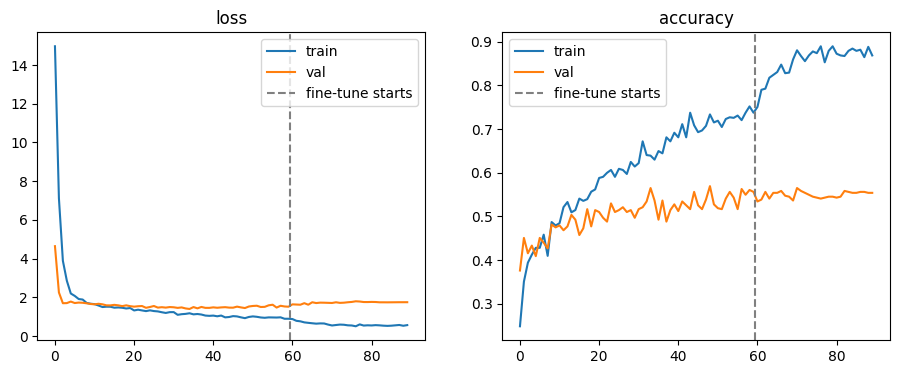

In [10]:
# Training curves (x-axis corresponds to epochs)
hist = {k: h1.history[k] + h2.history[k] for k in h1.history}
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (k, title) in zip(ax, [('loss', 'loss'), ('accuracy', 'accuracy')]):
    a.plot(hist[k], label='train'); a.plot(hist['val_' + k], label='val')
    a.axvline(len(h1.history['loss']) - 0.5, color='gray', ls='--', label='fine-tune starts')
    a.set_title(title); a.legend()
plt.show()

train window-level accuracy: 0.9881889820098877
val window-level accuracy: 0.5538461804389954
test window-level accuracy: 0.5490605235099792
file-level test accuracy: 0.6493506493506493
              precision    recall  f1-score   support

       anger       0.58      0.96      0.72        55
     boredom       0.69      0.75      0.72        36
     disgust       0.80      0.46      0.59        26
        fear       1.00      0.21      0.35        33
   happiness       0.28      0.19      0.22        27
     neutral       0.70      0.70      0.70        27
     sadness       0.82      1.00      0.90        27

    accuracy                           0.65       231
   macro avg       0.70      0.61      0.60       231
weighted avg       0.69      0.65      0.61       231



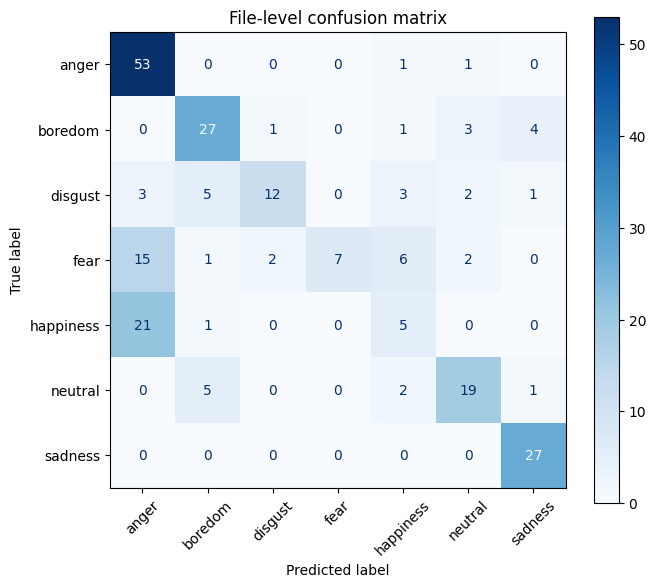

In [13]:
# accuracy evaluated on the test dataset per window
for name, X, y in [('train', X_tr, y_tr), ('val', X_val, y_val), ('test', X_te, y_test_int)]:
    print(name, 'window-level accuracy:', model.evaluate(X, y, verbose=0)[1])

"""
Since each file is segmented into various windows, the accuracy given by model.evaluate takes into account all of them
For a file-level accuracy, an average softmax over all windows of each file was applied
This way, if the majority of windows of a single file return the same emotion, this is the emotion predicted for the file
"""
probs = model.predict(X_te, batch_size=64, verbose=0)
df_p = pd.DataFrame(probs)
df_p['file'] = files_test
file_probs = df_p.groupby('file').mean()
file_true = pd.Series(y_test_int, index=files_test).groupby(level=0).first().loc[file_probs.index]
file_pred = file_probs.values.argmax(axis=1)

print('file-level test accuracy:', (file_pred == file_true.values).mean())
print(classification_report(file_true.values, file_pred, target_names=le.classes_))

cm = confusion_matrix(file_true.values, file_pred)

fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=True, xticks_rotation=45, values_format='d')
ax.set_title('File-level confusion matrix')
plt.tight_layout()
plt.show()

In [ ]:
# cell used to convert the trained model into the .onnx format
import tf2onnx
import onnx

# define input signature
input_signature = [tf.TensorSpec(shape=[None, X_tr.shape[1], X_tr.shape[2], 1],
                                dtype=tf.float32,
                                name="input")]

# use the model as a function
@tf.function
def model_func(input_tensor):
    return model(input_tensor)

onnx_model, _ = tf2onnx.convert.from_function(
    model_func,
    input_signature=input_signature,
    opset=13
)

# save the model
output_path = "model.onnx"
onnx.save_model(onnx_model, output_path)
print(f"Successfully converted and saved to {output_path}")

Successfully converted and saved to model.onnx
